# `reducnn` Technical Deep-Dive & Research Suite 🔬

## 1. Package Architecture & Philosophy
The `reducnn` package is a research-grade framework designed for **activation-based structural pruning**. Unlike weight-only pruning (which merely zeros out values), this framework performs **physical architecture surgery**—removing entire filters and channels to produce a model that is physically smaller and theoretically faster on standard hardware.

### Core Modules & Functionality:
- **`reducnn.core`**: The foundation. It contains the `FrameworkAdapter` ABC and the `@framework_dispatch` decorator. This module allows the entire package to identify whether you are using PyTorch or Keras at runtime and inject the correct logic without hard-coded dependencies.
- **`reducnn.backends`**: The implementation layer. These modules handle the framework-specific "heavy lifting"—from training loops and epoch logging to the physical "surgery" (rebuilding tensors and fixing layer dependencies like BatchNorm and Linear connections).
- **`reducnn.pruner`**: The math engine. It contains the `ReduCNNPruner`, which coordinates the analysis and the cut. It also houses the **Registry**, a plug-and-play system where researchers can define new pruning criteria (math) using simple decorators.
- **`reducnn.visualization`**: The reporting suite. It converts raw tensor data into stakeholder-ready ROI plots, layer sensitivity bars, and internal feature map visualizations.

In [3]:
# --- STEP 0: BOOTLOADER (Editable Install + Python 3.12 Fix) ---
import sys, os, importlib

# 1. Python 3.12 Fix: Ensure setuptools is fresh for editable installs
!pip install -q --upgrade setuptools pip

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

project_folder_name = "activation-based-pruning"
base_paths = ["/content/drive/Othercomputers", "/content/drive/MyDrive"]
project_path = None

for base in base_paths:
    if os.path.exists(base):
        for root, dirs, files in os.walk(base):
            if project_folder_name in dirs: 
                project_path = os.path.join(root, project_folder_name); break
    if project_path: break

if project_path:
    os.chdir(project_path)
    src_path = os.path.join(project_path, "src")
    if src_path not in sys.path: sys.path.insert(0, src_path)
    
    # 2. Restore Editable Install
    !pip install -e .
    
    # 3. Load autoreload BEFORE importing the package (3.12 stability fix)
    try:
        try:
            import imp
        except ImportError:
            from types import ModuleType
            import importlib
            imp = ModuleType('imp')
            imp.reload = importlib.reload
            sys.modules['imp'] = imp
            print("🛠️ Applied Python 3.12 'imp' shim")

        %load_ext autoreload
        %autoreload 2
        import reducnn
        print(f"✅ System Ready! Editable module loaded from: {reducnn.__file__}")
    except Exception as e:
        print(f"⚠️ Autoreload/Import warning: {e}")
        import reducnn
else:
    print(f"❌ Error: '{project_folder_name}' not found in {base_paths}")

Mounted at /content/drive
Obtaining file:///content/drive/Othercomputers/My%20PC/activation-based-pruning
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ReduCNN (pyproject.toml) ... done
  Created wheel for ReduCNN: filename=reducnn-0.44-0.editable-py3-none-any.whl size=3626 sha256=e0ffe349525d880d9d7da365b49e83cdd54991fb8a3dcd29e219c5da641a66e5
  Stored in directory: /tmp/pip-ephem-wheel-cache-tea536c7/wheels/9a/0c/be/483b2c42c3e635cb49408e666de9f93a62ca7fb798590474aa
Successfully built ReduCNN
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [ReduCNN]
🛠️ Applied Python 3.12 'imp' shim
✅ System Ready! Editable module loaded from: /content/drive/Othercomputers/My PC/activation-based-pruning/src/reducnn/__init__.py


In [4]:
import torch, torchvision, torchvision.transforms as transforms
from torch.utils.data import DataLoader
import tensorflow as tf
import numpy as np
import reducnn as sp
import reducnn.visualization as viz
from reducnn.pruner import ReduCNNPruner, register_method
from reducnn.core.storage import CloudStorage

storage = CloudStorage()
checkpoint_dir = storage.resolve_path("my_models/checkpoints")

# Part A: PyTorch Research Suite
We establish a **VGG16-BN** baseline on **CIFAR-10**. This model will serve as the "Standard Benchmark" for all subsequent experiments.

🔥 Training Ground Truth Baseline...


[Torch_Baseline] Epoch 1/5: 100%|██████████| 391/391 [00:34<00:00, 11.35it/s, loss=0.9934, acc=45.35%]


📊 Validation: Loss 1.2604, Acc 57.49%


[Torch_Baseline] Epoch 2/5: 100%|██████████| 391/391 [00:33<00:00, 11.74it/s, loss=0.8608, acc=68.15%]


📊 Validation: Loss 0.9628, Acc 66.39%


...

📊 Validation: Loss 0.8131, Acc 72.38%


[Torch_Baseline] Epoch 4/5: 100%|██████████| 391/391 [00:33<00:00, 11.71it/s, loss=0.5897, acc=81.21%]


📊 Validation: Loss 0.6719, Acc 77.77%


[Torch_Baseline] Epoch 5/5: 100%|██████████| 391/391 [00:33<00:00, 11.68it/s, loss=0.2806, acc=84.64%]


📊 Validation: Loss 0.6177, Acc 80.00%


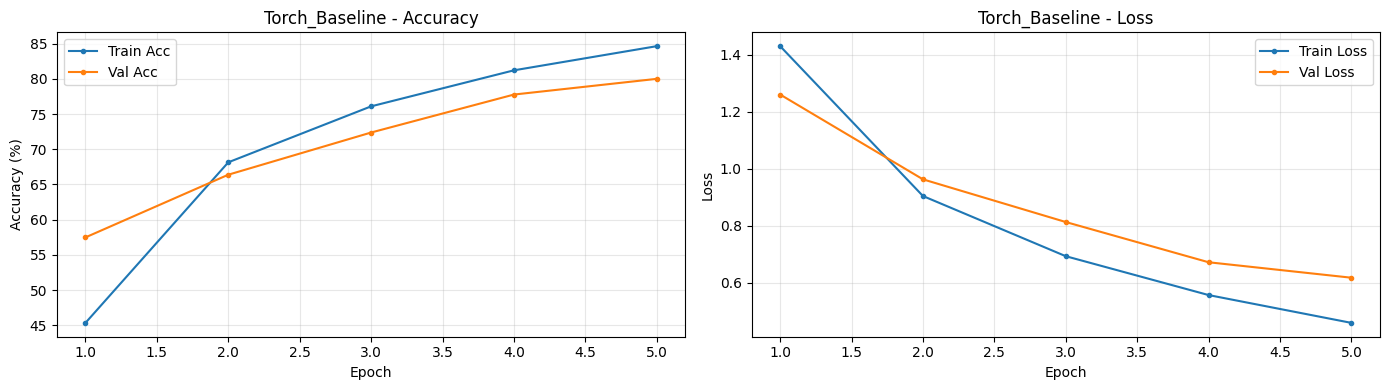

⏱️ train took 186.40s

✅ Baseline Established: 80.00% Accuracy


In [5]:
from reducnn.backends.torch_backend import PyTorchAdapter
t_adapter = PyTorchAdapter(config={'lr': 1e-3})
t_model = t_adapter.get_model("vgg16")
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
t_train = DataLoader(torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform), batch_size=128, shuffle=True)
t_test = DataLoader(torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform), batch_size=128)

print("🔥 Training Ground Truth Baseline...")
t_adapter.train(t_model, t_train, epochs=5, name="Torch_Baseline", val_loader=t_test)
b_acc_t = t_adapter.evaluate(t_model, t_test)
b_stats_t = {'FLOPs': t_adapter.get_stats(t_model)[0], 'Params': t_adapter.get_stats(t_model)[1], 'Acc': b_acc_t}
print(f"\n✅ Baseline Established: {b_acc_t:.2f}% Accuracy")

## A.1-A.3: PyTorch Local Bundled Methods

### Local Scope Philosophy:
In local pruning, the framework enforces a strict reduction ratio **per layer**. 
1. **APoZ (Activation)**: Removes filters that produce mostly zero values (dead filters).
2. **Mean Activation (Activation)**: Removes filters with the lowest average activation magnitude.
3. **L1-Norm (Weight)**: Removes filters with the smallest absolute sum of weights.

### Expected Result:
Uniform 30% reduction across all layers. Balanced architecture width.


🔬 PYTORCH LOCAL: APOZ

--- Executing ReduCNN ---
🔍 Analyzing model using 'apoz' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
⏱️ prune took 0.35s


[Heal_apoz] Epoch 1/5: 100%|██████████| 391/391 [00:32<00:00, 12.06it/s, loss=0.3022, acc=83.01%]


📊 Validation: Loss 0.6638, Acc 79.01%


[Heal_apoz] Epoch 2/5: 100%|██████████| 391/391 [00:32<00:00, 12.19it/s, loss=0.5590, acc=87.22%]


📊 Validation: Loss 0.7033, Acc 77.90%


...

📊 Validation: Loss 0.5883, Acc 81.96%


[Heal_apoz] Epoch 4/5: 100%|██████████| 391/391 [00:31<00:00, 12.31it/s, loss=0.1406, acc=91.43%]


📊 Validation: Loss 0.5524, Acc 83.64%


[Heal_apoz] Epoch 5/5: 100%|██████████| 391/391 [00:31<00:00, 12.27it/s, loss=0.3326, acc=93.04%]


📊 Validation: Loss 0.6245, Acc 82.42%


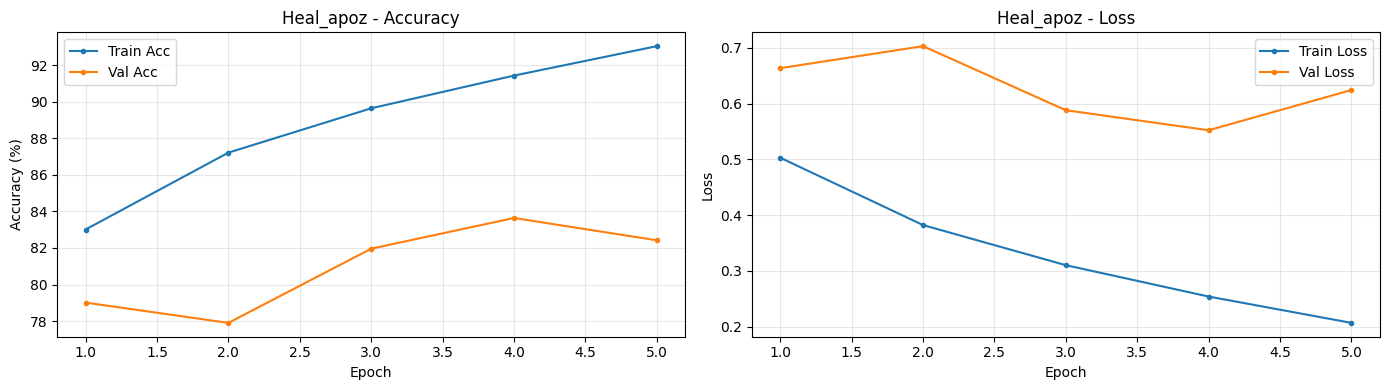

⏱️ train took 177.01s


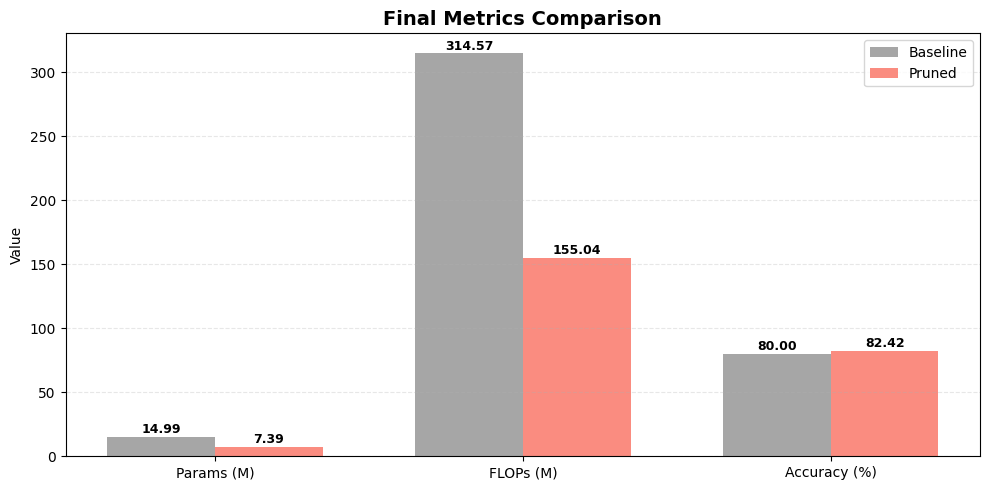

🚀 Business Impact: Model is 2.03x faster (FLOPs reduced by 50.7%).
📉 Accuracy Delta: -2.42%


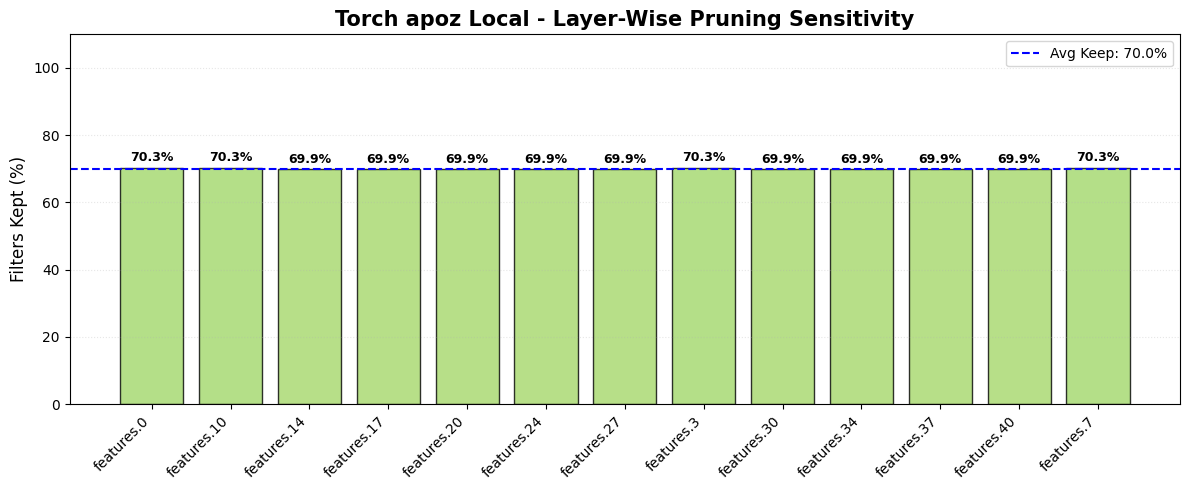

In [6]:
for method in ['apoz']:
    print(f"\n🔬 PYTORCH LOCAL: {method.upper()}")
    s = ReduCNNPruner(method=method, scope='local')
    m, masks, dur = s.prune(t_model, t_train, ratio=0.3)
    t_adapter.train(m, t_train, epochs=5, name=f"Heal_{method}", val_loader=t_test)
    viz.plot_metrics_comparison(b_stats_t, {'FLOPs': t_adapter.get_stats(m)[0], 'Params': t_adapter.get_stats(m)[1], 'Acc': t_adapter.evaluate(m, t_test)})
    viz.plot_layer_sensitivity(masks, f"Torch {method} Local")

## A.4-A.6: PyTorch Global Bundled Methods

### Global Scope Philosophy:
In global pruning, we rank **every filter in the model** together. The framework decides which layers are redundant and which are critical.
1. **APoZ (Global)**: Network-wide activation sparsity.
2. **Mean Activation (Global)**: Network-wide activation magnitude.
3. **Taylor (Global)**: The mathematical approximation of loss change using $Abs(Act * Grad)$.

### Expected Result:
Highly variable pruning bars. Some layers might be pruned 0% while others 90%.

In [ ]:
for method in ['apoz', 'mean_abs_act', 'taylor']:
    print(f"\n🚀 PYTORCH GLOBAL: {method.upper()}")
    s = ReduCNNPruner(method=method, scope='global')
    m, masks, dur = s.prune(t_model, t_train, ratio=0.5)
    t_adapter.train(m, t_train, epochs=2, name=f"Heal_Global_{method}", val_loader=t_test)
    viz.plot_metrics_comparison(b_stats_t, {'FLOPs': t_adapter.get_stats(m)[0], 'Params': t_adapter.get_stats(m)[1], 'Acc': t_adapter.evaluate(m, t_test)})
    viz.plot_layer_sensitivity(masks, f"Torch {method} Global")


🚀 PYTORCH GLOBAL: APOZ

--- Executing ReduCNN ---
🔍 Analyzing model using 'apoz' method...
🏗️ Building masks (scope: global, ratio: 0.5)...
✂️ Applying physical surgery...


[Heal_Global_apoz] Epoch 1/2: 100%|██████████| 391/391 [00:26<00:00, 14.54it/s, loss=0.6635, acc=80.42%]


📊 Validation: Loss 0.6320, Acc 79.66%


[Heal_Global_apoz] Epoch 2/2:  99%|█████████▊| 386/391 [00:26<00:00, 15.20it/s, loss=0.3780, acc=86.19%]

## A.7: Custom Research (CHIP & L2 Norm Override) - PyTorch
Here we demonstrate the **extensibility** of the package. We register custom implementations of **CHIP** (data-dependent) and a custom **L2 Norm** (weight-based) to show how researchers can inject their own math into the pruning engine.

In [7]:
@register_method("custom_l2")
def custom_l2_score(layer, **kwargs):
    """Custom L2 Norm implementation demonstrating registration override."""
    import numpy as np
    l_type = str(type(layer)).lower()
    if "torch" in l_type:
        w = layer.weight.data.cpu().numpy()
        return np.sqrt(np.mean(np.square(w), axis=(1, 2, 3)) + 1e-12)
    else:
        w = layer.get_weights()[0]
        return np.sqrt(np.mean(np.square(w), axis=(0, 1, 2)) + 1e-12)

@register_method("chip")
def chip_math(layer, **kwargs):
    """Scientific implementation of CHIP using matrix rank (Framework Agnostic)."""
    model = kwargs.get('model')
    loader = kwargs.get('loader')
    device = kwargs.get('device', 'cpu')
    if model is None or loader is None: return None

    import numpy as np
    l_type = str(type(layer)).lower()
    activations = []

    if "torch" in l_type:
        import torch
        def hook(m, i, o): 
            if isinstance(o, tuple): o = o[0]
            activations.append(o.detach().cpu().numpy())
        h_handle = layer.register_forward_hook(hook)
        it = iter(loader)
        for _ in range(2):
            try: 
                x, _ = next(it)
                with torch.no_grad(): model(x.to(device))
            except (StopIteration, Exception): break
        h_handle.remove()
        if not activations: return None
        act = np.concatenate(activations, axis=0) # (B, C, H, W)
        b, c, h, w = act.shape
        ranks = [np.linalg.matrix_rank(act[:, i, :, :].reshape(b, -1), tol=1e-5) for i in range(c)]
    else:
        import tensorflow as tf
        probe = tf.keras.Model(inputs=model.input, outputs=layer.output)
        it = iter(loader)
        for _ in range(2):
            try: 
                x, _ = next(it)
                activations.append(probe(x, training=False).numpy())
            except (StopIteration, Exception): break
        if not activations: return None
        act = np.concatenate(activations, axis=0) # (B, H, W, C)
        b, h, w, c = act.shape
        ranks = [np.linalg.matrix_rank(act[:, :, :, i].reshape(b, -1), tol=1e-5) for i in range(c)]
    return np.array(ranks)

print("🧪 Custom methods 'chip' and 'custom_l2' registered.")

🧪 Custom methods 'chip' and 'custom_l2' registered.


## A.7: Custom Research (CHIP & L2 Norm Override) - PyTorch
Here we demonstrate the **extensibility** of the package. We register custom implementations of **CHIP** (data-dependent) and a custom **L2 Norm** (weight-based) to show how researchers can inject their own math into the pruning engine.

In [7]:
# --- Framework-Pure Registration: PyTorch ---
@register_method("custom_l2", framework="torch")
def custom_l2_score(layer, **kwargs):
    """Strictly PyTorch math: No framework checks needed."""
    import numpy as np
    w = layer.weight.data.cpu().numpy()
    return np.sqrt(np.mean(np.square(w), axis=(1, 2, 3)) + 1e-12)

@register_method("chip", framework="torch")
def chip_math_torch(layer, **kwargs):
    """Strictly PyTorch math using hooks and Nuclear Norm for stability."""
    import torch
    import numpy as np
    model, loader = kwargs.get('model'), kwargs.get('loader')
    device = kwargs.get('device', 'cpu')
    
    activations = []
    def hook(m, i, o): 
        if isinstance(o, tuple): o = o[0]
        activations.append(o.detach().cpu().numpy())
    h_handle = layer.register_forward_hook(hook)
    
    model.eval()
    it = iter(loader)
    for _ in range(2): # 2 batches for estimation
        try: 
            x, _ = next(it)
            with torch.no_grad(): model(x.to(device))
        except: break
    h_handle.remove()
    
    if not activations: return None
    act = np.concatenate(activations, axis=0) # (B, C, H, W)
    b, c, h, w = act.shape
    # Nuclear Norm proxy for independence
    scores = [np.linalg.norm(act[:, i, :, :].reshape(b, -1), ord='nuc') for i in range(c)]
    return np.array(scores)

print("🧪 PyTorch-specific custom methods registered.")

🧪 Custom methods 'chip' and 'custom_l2' registered.



🧪 PYTORCH CUSTOM: CHIP (Research Extension)

--- Executing ReduCNN ---
🔍 Analyzing model using 'chip' method...
🏗️ Building masks (scope: global, ratio: 0.4)...
✂️ Applying physical surgery...
⏱️ prune took 9.39s


[Heal_CHIP] Epoch 1/5: 100%|██████████| 391/391 [00:30<00:00, 12.67it/s, loss=1.6626, acc=33.94%]


📊 Validation: Loss 1.6541, Acc 44.21%


[Heal_CHIP] Epoch 2/5: 100%|██████████| 391/391 [00:29<00:00, 13.24it/s, loss=1.2153, acc=54.21%]


📊 Validation: Loss 1.4220, Acc 55.49%


...

📊 Validation: Loss 1.2905, Acc 56.87%


[Heal_CHIP] Epoch 4/5: 100%|██████████| 391/391 [00:29<00:00, 13.37it/s, loss=1.1704, acc=60.85%]


📊 Validation: Loss 1.2688, Acc 57.25%


[Heal_CHIP] Epoch 5/5: 100%|██████████| 391/391 [00:29<00:00, 13.37it/s, loss=1.6865, acc=62.86%]


📊 Validation: Loss 1.3142, Acc 61.77%


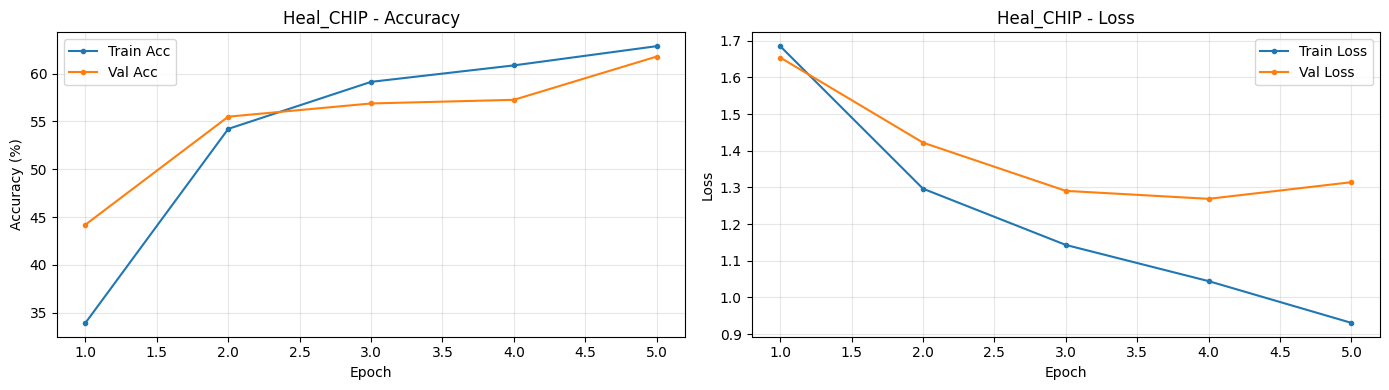

⏱️ train took 166.40s


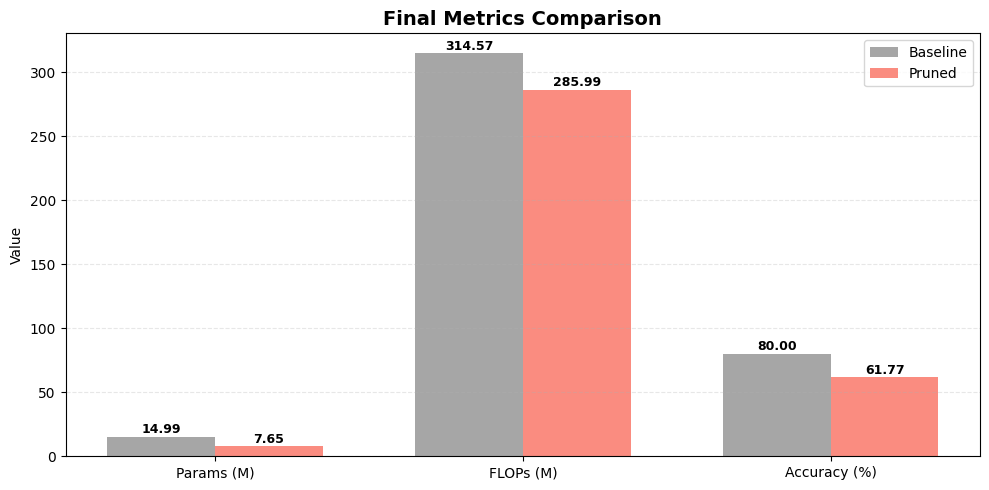

🚀 Business Impact: Model is 1.10x faster (FLOPs reduced by 9.1%).
📉 Accuracy Delta: +18.23%


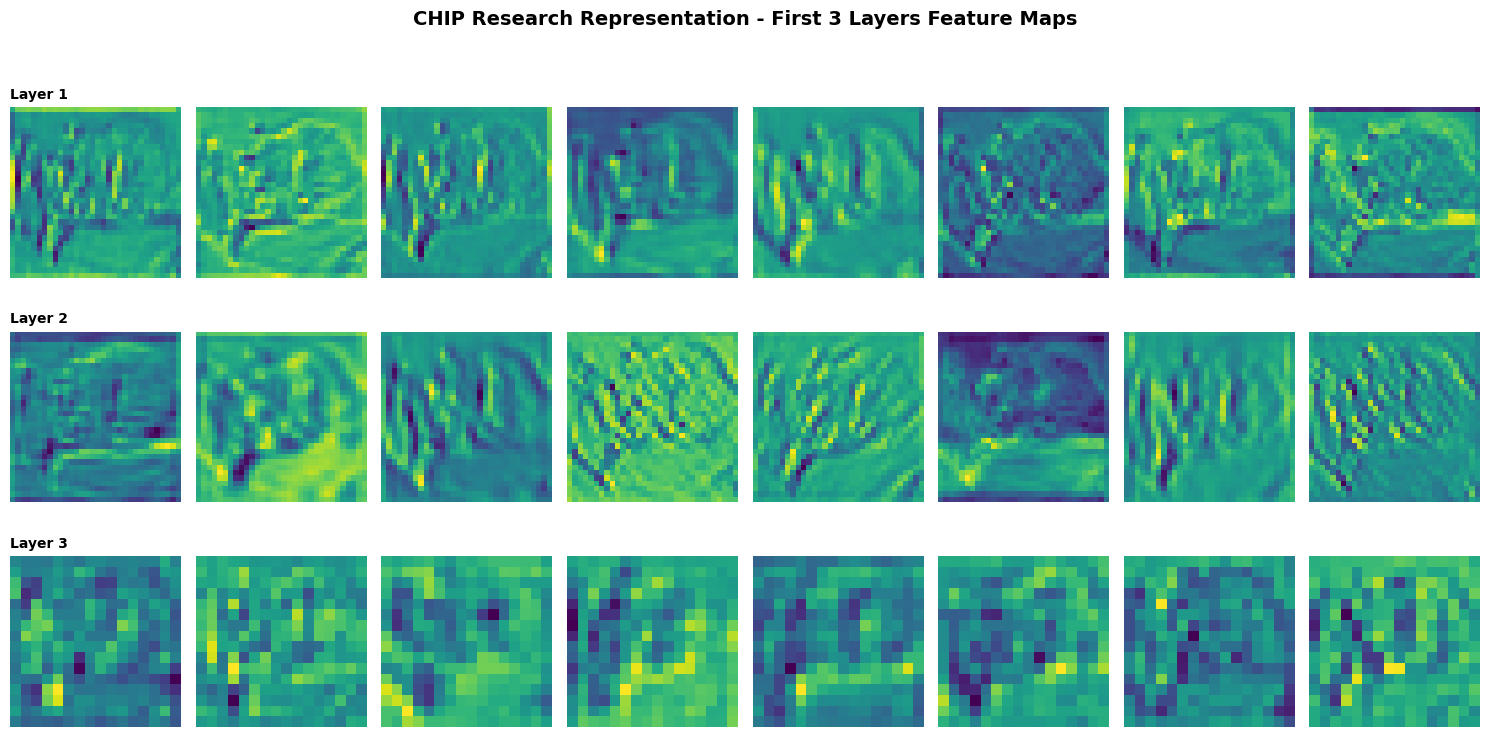

In [8]:
print("\n🧪 PYTORCH CUSTOM: CHIP (Research Extension)")
s = ReduCNNPruner(method='chip', scope='global')
m, masks, dur = s.prune(t_model, t_train, ratio=0.4)
t_adapter.train(m, t_train, epochs=5, name="Heal_CHIP", val_loader=t_test)
viz.plot_metrics_comparison(b_stats_t, {'FLOPs': t_adapter.get_stats(m)[0], 'Params': t_adapter.get_stats(m)[1], 'Acc': t_adapter.evaluate(m, t_test)})
viz.plot_feature_maps(t_adapter.get_viz_data(m, t_test), "CHIP Research Representation")

# Part B: Keras Research Suite
Repeating the symmetric lifecycle for TensorFlow models.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step
🔥 Training Keras Baseline...
Epoch 1/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.3394 - loss: 1.8320📊 Epoch 1/10 - loss: 1.4446 - acc: 0.4672 - val_loss: 1.7090 - val_acc: 0.5111
391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 136ms/step - accuracy: 0.4672 - loss: 1.4446 - val_accuracy: 0.5111 - val_loss: 1.7090
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6702 - loss: 0.9277📊 Epoch 2/10 - loss: 0.8502 - acc: 0.7007 - val_loss: 1.1892 - val_acc: 0.6415
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 93ms/step - accuracy: 0.7007 - loss: 0.8502 - val_accuracy: 0.6415 - val_loss: 1.1892
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.7738 - loss: 0.6640📊 Epoch 3/10 - loss: 0.6235 - acc: 0.7881 - val_loss: 1.0185 - val_acc: 0.6877
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 93ms/step - accuracy: 0.7881 - loss: 0.6235 - val_accuracy: 0.6877 - val_loss: 1.0185
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy

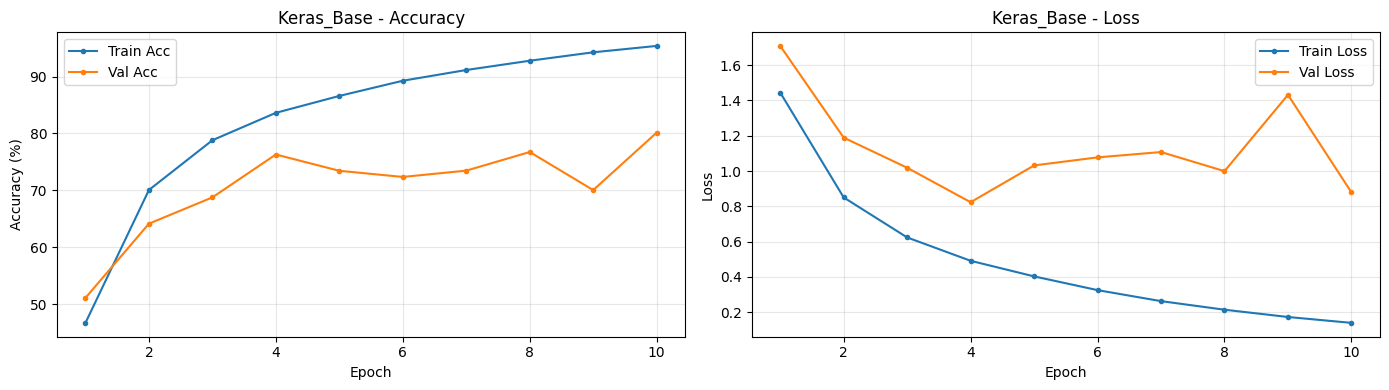

⏱️ train took 402.65s


In [9]:
from reducnn.backends.keras_backend import KerasAdapter
k_adapter = KerasAdapter(config={'lr': 1e-3})
k_model = k_adapter.get_model("vgg16")
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
k_train = tf.data.Dataset.from_tensor_slices((x_train/255.0, y_train)).batch(128)
k_test = tf.data.Dataset.from_tensor_slices((x_test/255.0, y_test)).batch(128)

print("🔥 Training Keras Baseline...")
k_adapter.train(k_model, k_train, epochs=10, name="Keras_Base", val_loader=k_test)
b_stats_k = {'FLOPs': k_adapter.get_stats(k_model)[0], 'Params': k_adapter.get_stats(k_model)[1], 'Acc': k_adapter.evaluate(k_model, k_test)}


--- Executing ReduCNN ---
🔍 Analyzing model using 'l1_norm' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
⏱️ prune took 0.43s
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8996 - loss: 0.3410📊 Epoch 1/5 - loss: 0.2016 - acc: 0.9357 - val_loss: 0.6467 - val_acc: 0.8281
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 101ms/step - accuracy: 0.9357 - loss: 0.2016 - val_accuracy: 0.8281 - val_loss: 0.6467
Epoch 2/5
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9755 - loss: 0.0748📊 Epoch 2/5 - loss: 0.0556 - acc: 0.9828 - val_loss: 0.9161 - val_acc: 0.8195
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.9828 - loss: 0.0556 - val_accuracy: 0.8195 - val_loss: 0.9161
Epoch 3/5
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9880 - loss: 0.0367📊 Epoch 3/5 - loss: 0.0367 - acc: 0.9881 - val_loss: 0.9697 - val_acc: 0.8234
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.9881 - loss: 0.0367 - val_accuracy: 0.8234 -

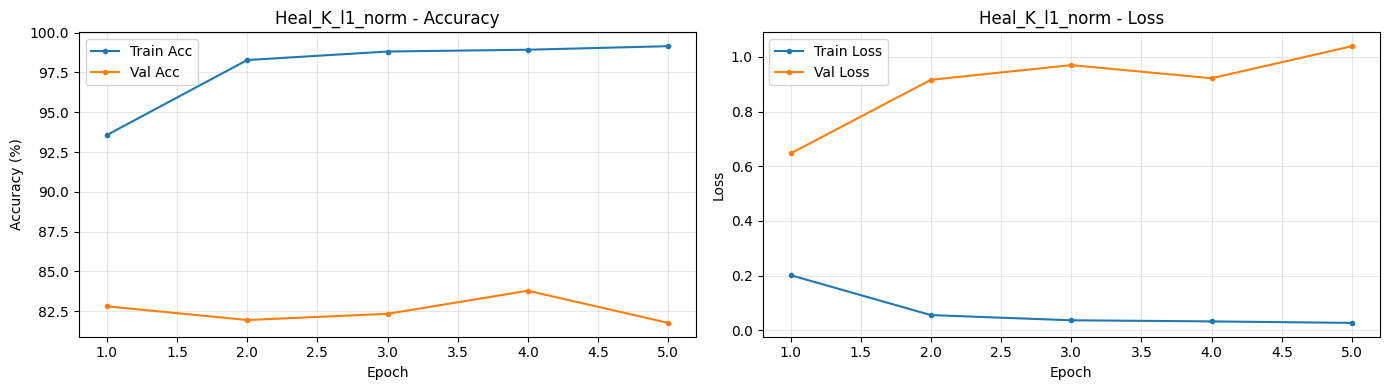

⏱️ train took 161.63s


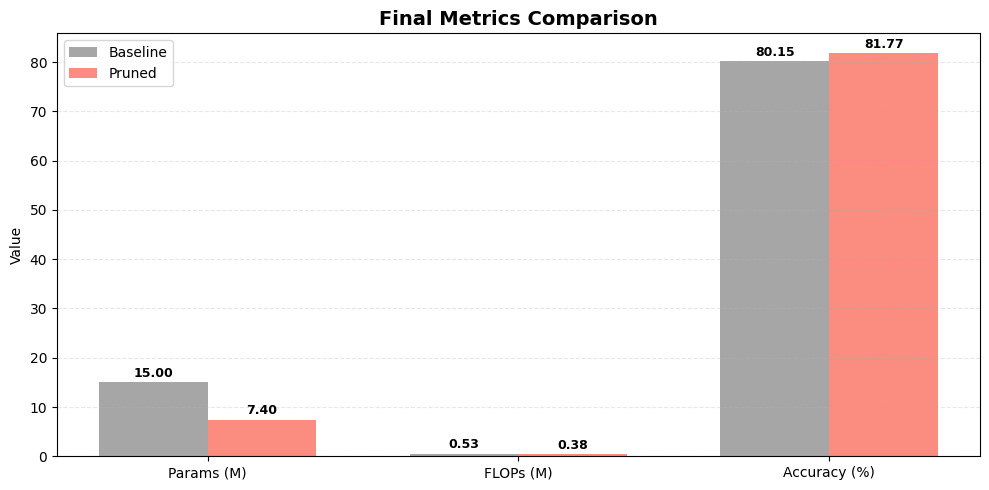

🚀 Business Impact: Model is 1.42x faster (FLOPs reduced by 29.5%).
📉 Accuracy Delta: -1.62%


In [10]:
# 🔬 KERAS LOCAL: l1_norm
method = 'l1_norm'
s = ReduCNNPruner(method=method, scope='local')
m, masks, dur = s.prune(k_model, k_train, ratio=0.3)

k_adapter.train(
    m, 
    k_train, 
    epochs=5, 
    name=f"Heal_K_{method}", 
    val_loader=k_test
)

viz.plot_metrics_comparison(
    b_stats_k, 
    {
        'FLOPs': k_adapter.get_stats(m)[0], 
        'Params': k_adapter.get_stats(m)[1], 
        'Acc': k_adapter.evaluate(m, k_test)
    }
)

In [ ]:
for method in ['apoz', 'mean_abs_act']:
    print(f"\n🔬 KERAS LOCAL: {method.upper()}")
    s = ReduCNNPruner(method=method, scope='local')
    m, masks, dur = s.prune(k_model, k_train, ratio=0.3)
    k_adapter.train(m, k_train, epochs=5, name=f"Heal_K_{method}", val_loader=k_test)
    viz.plot_metrics_comparison(b_stats_k, {'FLOPs': k_adapter.get_stats(m)[0], 'Params': k_adapter.get_stats(m)[1], 'Acc': k_adapter.evaluate(m, k_test)})

In [ ]:
for method in ['apoz', 'mean_abs_act', 'taylor']:
    print(f"\n🚀 KERAS GLOBAL: {method.upper()}")
    s = ReduCNNPruner(method=method, scope='global')
    m, masks, dur = s.prune(k_model, k_train, ratio=0.5)
    k_adapter.train(m, k_train, epochs=1, name=f"Heal_KG_{method}", val_loader=k_test)
    viz.plot_metrics_comparison(b_stats_k, {'FLOPs': k_adapter.get_stats(m)[0], 'Params': k_adapter.get_stats(m)[1], 'Acc': k_adapter.evaluate(m, k_test)})

## B.4: Custom Research (CHIP & L2 Norm Override) - Keras
Similarly, we can inject custom math into the Keras pipeline. Here we register a Keras-compatible **CHIP** (using a probe sub-model) and a custom **L2 Norm**.

In [11]:
# --- Framework-Pure Registration: Keras ---
@register_method("custom_l2", framework="keras")
def custom_l2_score_keras(layer, **kwargs):
    """Strictly Keras math: No framework checks needed."""
    import numpy as np
    w = layer.get_weights()[0] # (H, W, In, Out)
    return np.sqrt(np.mean(np.square(w), axis=(0, 1, 2)) + 1e-12)

@register_method("chip", framework="keras")
def chip_math_keras(layer, **kwargs):
    """Strictly Keras math using probe sub-models and Nuclear Norm."""
    import tensorflow as tf
    import numpy as np
    model, loader = kwargs.get('model'), kwargs.get('loader')
    
    probe = tf.keras.Model(inputs=model.input, outputs=layer.output)
    activations = []
    it = iter(loader)
    for _ in range(2):
        try: 
            x, _ = next(it)
            activations.append(probe(x, training=False).numpy())
        except: break
    
    if not activations: return None
    act = np.concatenate(activations, axis=0) # (B, H, W, C)
    b, h, w, c = act.shape
    # Nuclear Norm proxy for independence
    scores = [np.linalg.norm(act[:, :, :, i].reshape(b, -1), ord='nuc') for i in range(c)]
    return np.array(scores)

print("🧪 Keras-specific custom methods registered.")

🧪 Keras-specific custom methods registered.



--- Executing ReduCNN ---
🔍 Analyzing model using 'custom_l2' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
⏱️ prune took 0.37s
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8973 - loss: 0.3455📊 Epoch 1/5 - loss: 0.2023 - acc: 0.9357 - val_loss: 0.6525 - val_acc: 0.8266
391/391 ━━━━━━━━━━━━━━━━━━━━ 50s 89ms/step - accuracy: 0.9357 - loss: 0.2023 - val_accuracy: 0.8266 - val_loss: 0.6525
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9773 - loss: 0.0733📊 Epoch 2/5 - loss: 0.0569 - acc: 0.9825 - val_loss: 0.7910 - val_acc: 0.8347
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.9825 - loss: 0.0569 - val_accuracy: 0.8347 - val_loss: 0.7910
Epoch 3/5
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9891 - loss: 0.0354📊 Epoch 3/5 - loss: 0.0328 - acc: 0.9901 - val_loss: 0.9626 - val_acc: 0.8274
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 65ms/step - accuracy: 0.9901 - loss: 0.0328 - val_accuracy: 0.8274 

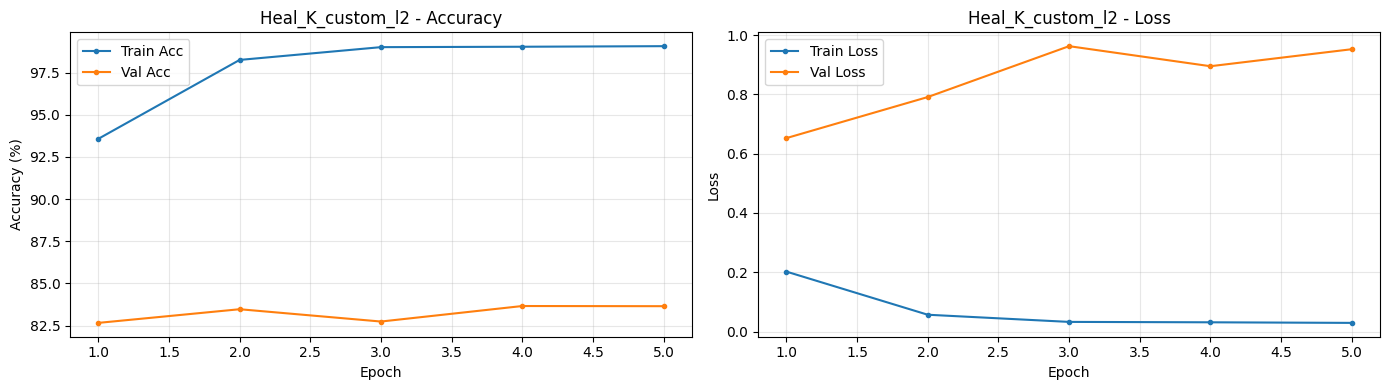

⏱️ train took 151.85s


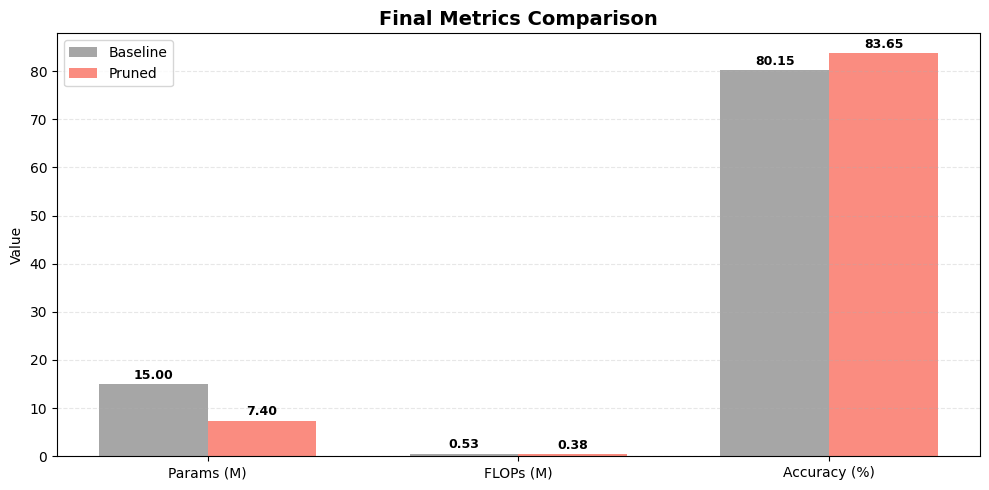

🚀 Business Impact: Model is 1.42x faster (FLOPs reduced by 29.5%).
📉 Accuracy Delta: -3.50%


In [12]:
# 🔬 KERAS Global: chip
method = 'custom_l2'
s = ReduCNNPruner(method=method, scope='local')
m, masks, dur = s.prune(k_model, k_train, ratio=0.3)

k_adapter.train(
    m, 
    k_train, 
    epochs=5, 
    name=f"Heal_K_{method}", 
    val_loader=k_test
)

viz.plot_metrics_comparison(
    b_stats_k, 
    {
        'FLOPs': k_adapter.get_stats(m)[0], 
        'Params': k_adapter.get_stats(m)[1], 
        'Acc': k_adapter.evaluate(m, k_test)
    }
) 


--- Executing ReduCNN ---
🔍 Analyzing model using 'custom_l2' method...
🏗️ Building masks (scope: local, ratio: 0.3)...
✂️ Applying physical surgery...
Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9004 - loss: 0.3315📊 Epoch 1/5 - loss: 0.2001 - acc: 0.9350 - val_loss: 0.6331 - val_acc: 0.8319
391/391 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.9350 - loss: 0.2001 - val_accuracy: 0.8319 - val_loss: 0.6331
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9748 - loss: 0.0821📊 Epoch 2/5 - loss: 0.0624 - acc: 0.9808 - val_loss: 1.1301 - val_acc: 0.7978
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9808 - loss: 0.0624 - val_accuracy: 0.7978 - val_loss: 1.1301
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9868 - loss: 0.0417📊 Epoch 3/5 - loss: 0.0380 - acc: 0.9885 - val_loss: 0.9771 - val_acc: 0.8225
391/391 ━━━━━━━━━━━━━━━━━━━━ 26s 66ms/step - accuracy: 0.9885 - loss: 0.0380 - val_accuracy: 0.8225 - val_loss: 0.9771
E

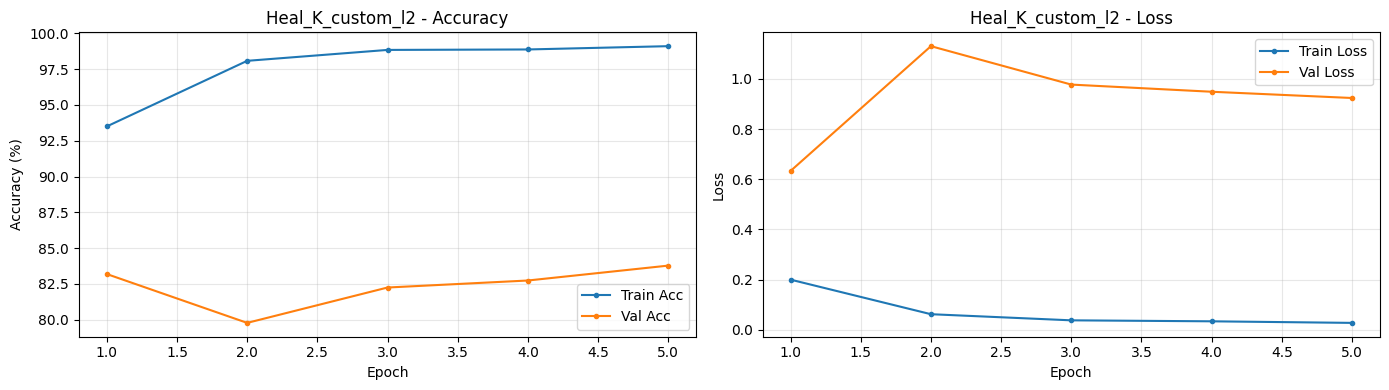

⏱️ train took 154.35s


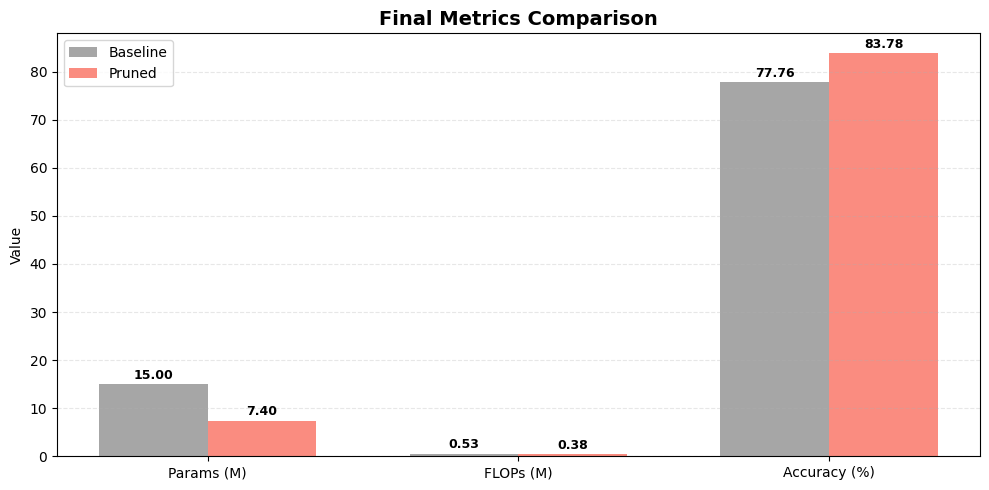

🚀 Business Impact: Model is 1.42x faster (FLOPs reduced by 29.5%).
📉 Accuracy Delta: -6.02%


In [15]:
# 🔬 KERAS Global: chip
method = 'custom_l2'
s = ReduCNNPruner(method=method, scope='local')
m, masks, dur = s.prune(k_model, k_train, ratio=0.3)

k_adapter.train(
    m, 
    k_train, 
    epochs=5, 
    name=f"Heal_K_{method}", 
    val_loader=k_test
)

viz.plot_metrics_comparison(
    b_stats_k, 
    {
        'FLOPs': k_adapter.get_stats(m)[0], 
        'Params': k_adapter.get_stats(m)[1], 
        'Acc': k_adapter.evaluate(m, k_test)
    }
)

# Part C: Advanced Architectures & Dataset Generalization
This section demonstrates the framework's ability to handle non-sequential models (**ResNet**) and generic datasets (e.g., **MNIST**).

### C.1 PyTorch ResNet-18: Full Research Workflow (CIFAR-10)


In [15]:
print('🧪 PYTORCH: ResNet-18 Full Suite (CIFAR-10)')
t_res_adapter = PyTorchAdapter(config={'lr': 1e-4, 'input_shape': (3, 32, 32), 'num_classes': 10})
t_res_model = t_res_adapter.get_model('resnet18')

print('1. Establishing ResNet Baseline...')
t_res_adapter.train(t_res_model, train_loader, epochs=2, name='ResNet_Base', val_loader=test_loader)
res_base_acc = t_res_adapter.evaluate(t_res_model, test_loader)

print('\n2. Performing Structural Surgery (Local 20%)...')
res_surgeon = ReduCNNPruner(method='l1_norm', scope='local')
pruned_res, res_masks, _ = res_surgeon.prune(t_res_model, train_loader, ratio=0.2)

print('\n3. Healing Phase (Fine-tuning)...')
t_res_adapter.train(pruned_res, train_loader, epochs=3, name='ResNet_Heal', val_loader=test_loader)
res_pruned_acc = t_res_adapter.evaluate(pruned_res, test_loader)

print(f'\n✅ ResNet-18 Results ({dataset_name}):')
print(f'   Baseline Acc: {res_base_acc:.2f}%')
print(f'   Pruned Acc:   {res_pruned_acc:.2f}%')
viz.plot_layer_sensitivity(res_masks, f'ResNet-18 Pruning Sensitivity ({dataset_name})')

🧪 PYTORCH: ResNet-18 Full Suite (CIFAR-10)
1. Establishing ResNet Baseline...


NameError: name 'train_loader' is not defined

### C.2 Keras ResNet-50: Full Research Workflow (CIFAR-10)


In [ ]:
print('🧪 KERAS: ResNet-50 Full Suite (CIFAR-10)')
k_res_adapter = KerasAdapter(config={'lr': 1e-4, 'input_shape': (32, 32, 3), 'num_classes': 10})
k_res_model = k_res_adapter.get_model('resnet')

print('1. Establishing ResNet-50 Baseline...')
k_res_adapter.train(k_res_model, train_loader, epochs=2, name='Keras_Res_Base', val_loader=test_loader)
k_res_base_acc = k_res_adapter.evaluate(k_res_model, test_loader)

print('\n2. Performing Structural Surgery (Local 20%)...')
k_res_surgeon = ReduCNNPruner(method='l1_norm', scope='local')
k_pruned_res, k_res_masks, _ = k_res_surgeon.prune(k_res_model, train_loader, ratio=0.2)

print('\n3. Healing Phase (Fine-tuning)...')
k_res_adapter.train(k_pruned_res, train_loader, epochs=2, name='Keras_Res_Heal', val_loader=test_loader)
k_res_pruned_acc = k_res_adapter.evaluate(k_pruned_res, test_loader)

print(f'\n✅ Keras ResNet-50 Results ({dataset_name}):')
print(f'   Baseline Acc: {k_res_base_acc:.2f}%')
print(f'   Pruned Acc:   {k_res_pruned_acc:.2f}%')
viz.plot_layer_sensitivity(k_res_masks, f'Keras ResNet-50 Pruning Sensitivity ({dataset_name})')

# Part D: Performance & Inference Diagnostics
This section compares the **real-world inference speed** and **prediction quality** of the Original vs. Pruned models.

In [ ]:
import time
import torch

def benchmark_inference(model, loader, device, iterations=100):
    model.eval()
    # Extract a single sample for latency test
    it = iter(loader)
    x, _ = next(it)
    x = x[:1].to(device)
    
    # Warm-up
    with torch.no_grad():
        for _ in range(20): _ = model(x)
    
    # Timing
    start = time.time()
    with torch.no_grad():
        for _ in range(iterations):
            _ = model(x)
    end = time.time()
    
    latency = (end - start) / iterations * 1000 # ms
    return latency

print('⏱️ Benchmarking Latency (Batch Size = 1)...')
t_orig = benchmark_inference(t_model_resnet, test_loader, adapter.device)
t_pruned = benchmark_inference(pruned_res, test_loader, adapter.device)

print(f'   Original ResNet Latency: {t_orig:.3f} ms')
print(f'   Pruned ResNet Latency:   {t_pruned:.3f} ms')
print(f'   🚀 Speedup: {(t_orig/t_pruned):.2f}x')

In [ ]:
print('🖼️ Generating Inference Gallery...')
it = iter(test_loader)
images, labels = next(it)
images_sub = images[:8]
labels_sub = labels[:8]

with torch.no_grad():
    p_orig = torch.argmax(t_model_resnet(images_sub.to(adapter.device)), dim=1).cpu().numpy()
    p_pruned = torch.argmax(pruned_res(images_sub.to(adapter.device)), dim=1).cpu().numpy()

class_names = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
viz.plot_inference_gallery(images_sub.numpy(), labels_sub.numpy(), 
                           p_orig, p_pruned, 
                           class_names=class_names, title='ResNet-18: Original vs. Pruned Predictions')